<a href="https://colab.research.google.com/github/Pensive1881/DSR44_2025/blob/main/DSR44_Gensim_Exercise_Dune.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!wget -nc --user-agent="Mozilla/5.0" -O "A_Voyage_to_Arcturus.txt" "https://www.gutenberg.org/files/1329/1329-0.txt"
!wget -nc --user-agent="Mozilla/5.0" -O "The_Night_Land.txt"       "https://www.gutenberg.org/files/10662/10662-0.txt"
!wget -nc --user-agent="Mozilla/5.0" -O "Erewhon.txt"              "https://www.gutenberg.org/files/1906/1906-0.txt"
!wget -nc --user-agent="Mozilla/5.0" -O "Herland.txt"              "https://www.gutenberg.org/files/32/32-0.txt"

--2025-10-21 10:08:56--  https://www.gutenberg.org/files/1329/1329-0.txt
Resolving www.gutenberg.org (www.gutenberg.org)... 152.19.134.47, 2610:28:3090:3000:0:bad:cafe:47
Connecting to www.gutenberg.org (www.gutenberg.org)|152.19.134.47|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 554787 (542K) [text/plain]
Saving to: ‘A_Voyage_to_Arcturus.txt’

A_Voyage_to_Arcturu 100%[===================>] 541.78K   597KB/s    in 0.9s    

2025-10-21 10:08:59 (597 KB/s) - ‘A_Voyage_to_Arcturus.txt’ saved [554787/554787]

--2025-10-21 10:08:59--  https://www.gutenberg.org/files/10662/10662-0.txt
Resolving www.gutenberg.org (www.gutenberg.org)... 152.19.134.47, 2610:28:3090:3000:0:bad:cafe:47
Connecting to www.gutenberg.org (www.gutenberg.org)|152.19.134.47|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1004039 (981K) [text/plain]
Saving to: ‘The_Night_Land.txt’

The_Night_Land.txt  100%[===================>] 980.51K   894KB/s    in 1.1s    

2025

In [3]:
!ls -l

total 2292
-rw-r--r-- 1 root root  554787 Oct 29  2024 A_Voyage_to_Arcturus.txt
-rw-r--r-- 1 root root  472869 Aug  5 11:28 Erewhon.txt
-rw-r--r-- 1 root root  302654 Sep 17 09:34 Herland.txt
drwxr-xr-x 1 root root    4096 Oct 17 22:29 sample_data
-rw-r--r-- 1 root root 1004039 May 11 12:07 The_Night_Land.txt


In [4]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 68.5 MB/s eta 0:00:00


In [5]:
import os
import logging
import multiprocessing
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess
from nltk.tokenize import sent_tokenize
import nltk
nltk.download('punkt')
import numpy as np
import seaborn as sns
from scipy import spatial
import matplotlib.pyplot as plt

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [6]:
from gensim.test.utils import datapath
from gensim import utils

class MyCorpus:
    """An iterator that yields sentences (lists of str)."""

    def __init__(self):
        self.lines = []

        files = os.listdir(".")
        files = [file for file in files if file.endswith(".txt")]
        print(f"Found {len(files)} files")

        for file in files:
            for line in open(file):
                self.lines += [line]
        print(f"Got {len(self.lines)} lines.")

    def __iter__(self):
        for line in self.lines:
            preprocessed_line = utils.simple_preprocess(line)
            yield preprocessed_line

In [7]:
import gensim.models

sentences = MyCorpus()

model = gensim.models.Word2Vec(
    sentences=sentences,
    sg=1,
    vector_size=300,
    window=20,
    min_count=3,
    workers=multiprocessing.cpu_count()
)

print("Done.")

Found 4 files
Got 43820 lines.
Done.


In [11]:
model.wv.most_similar("love", topn=20)

[('joy', 0.8727012872695923),
 ('understanding', 0.8634659647941589),
 ('wisdom', 0.8630456328392029),
 ('sympathy', 0.8577464818954468),
 ('pride', 0.8574082255363464),
 ('delight', 0.8496174216270447),
 ('thoughts', 0.8455907106399536),
 ('honour', 0.842602550983429),
 ('shame', 0.837155818939209),
 ('happiness', 0.8317342400550842),
 ('soul', 0.8311943411827087),
 ('belief', 0.8309376835823059),
 ('secret', 0.8249031901359558),
 ('glad', 0.823884129524231),
 ('manhood', 0.8218482732772827),
 ('mother', 0.8198274374008179),
 ('loved', 0.8194403052330017),
 ('dear', 0.8186227679252625),
 ('lovely', 0.8155872225761414),
 ('pain', 0.8152177929878235)]

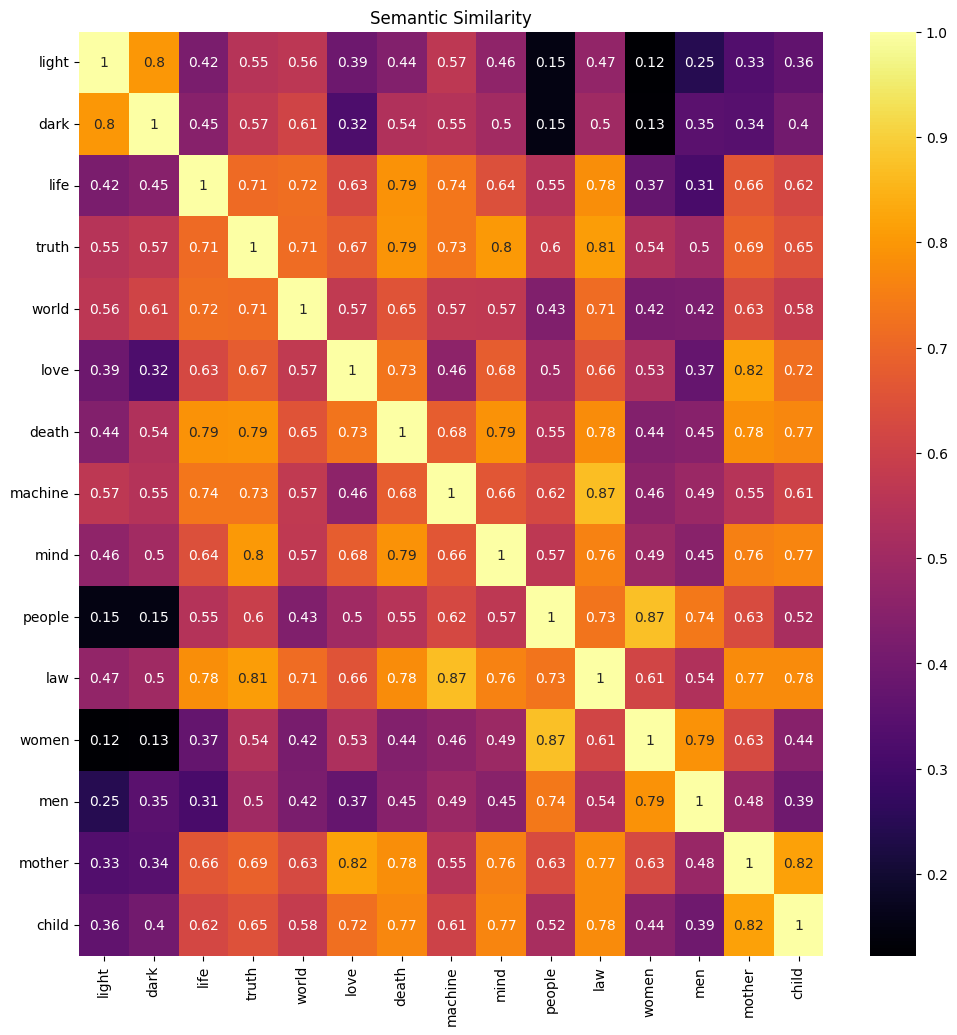

In [13]:
def plot_similarities(words):
    features = [np.array(model.wv[word]) for word in words]

    similarities = np.zeros((len(features), len(features)))
    for index1, feature1 in enumerate(features):
        for index2, feature2 in enumerate(features):
            similarities[index1, index2] = 1 - spatial.distance.cosine(feature1, feature2)

    fig, ax = plt.subplots(figsize=(12, 12))
    g = sns.heatmap(
        similarities,
        annot=True,
        xticklabels=words,
        yticklabels=words,
        cmap="inferno"
    )
    g.set_xticklabels(words, rotation=90)
    g.set_yticklabels(words, rotation=0)
    g.set_title("Semantic Similarity")

words = [
    "light","dark","life","truth","world","love","death","machine",
    "mind","people","law","women","men","mother","child"
]
plot_similarities(words)